# New York City Airbnb Open Data Analysis
Importing and analyzing the New York City Airbnb Open Data dataset.

In [1]:
%pip install kagglehub


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:

import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

100%|██████████| 2.44M/2.44M [00:00<00:00, 9.03MB/s]

Extracting files...
Path to dataset files: /Users/soroosh/.cache/kagglehub/datasets/dgomonov/new-york-city-airbnb-open-data/versions/3


In [3]:

# Find and load the CSV file
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if csv_files:
    # Load the first CSV found
    file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(file_path)
    print(f"Successfully loaded: {csv_files[0]}")
    print(f"Shape: {df.shape}")
else:
    print("No CSV files found in the dataset path.")

# Display first few rows
df.head()

Successfully loaded: AB_NYC_2019.csv
Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


# =============================================================================
# STEP 2: DATA CLEANUP
# =============================================================================

## 2.1 Data Profiling - Identify and examine the data

In [4]:
# Store original record count for reporting
original_record_count = len(df)
print(f"Original number of records: {original_record_count}")
print(f"Original number of columns: {len(df.columns)}")

# Display basic info about the dataset
print("\n--- Data Types and Non-Null Counts ---")
df.info()

# Check column names
print("\n--- Column Names ---")
print(df.columns.tolist())

Original number of records: 48895
Original number of columns: 16

--- Data Types and Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11 

In [5]:
# Check for missing values in each column
print("--- Missing Values by Column ---")
missing_data = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing_data, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

--- Missing Values by Column ---
                   Missing Count  Missing %
name                          16       0.03
host_name                     21       0.04
last_review                10052      20.56
reviews_per_month          10052      20.56


## 2.2 Standardize Column Names

In [6]:
# Standardize column names: lowercase, replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Rename columns for clarity
column_renames = {
    'neighbourhood_group': 'borough',
    'neighbourhood': 'neighborhood',
    'calculated_host_listings_count': 'host_listing_count'
}
df.rename(columns=column_renames, inplace=True)

print("Updated column names:")
print(df.columns.tolist())

Updated column names:
['id', 'name', 'host_id', 'host_name', 'borough', 'neighborhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'host_listing_count', 'availability_365']


## 2.3 Standardize Data Values

In [7]:
# Standardize text columns - strip whitespace and title case for names
df['host_name'] = df['host_name'].str.strip().str.title()
df['name'] = df['name'].str.strip()

# Standardize categorical columns - title case for consistency
df['borough'] = df['borough'].str.strip().str.title()
df['neighborhood'] = df['neighborhood'].str.strip().str.title()
df['room_type'] = df['room_type'].str.strip().str.title()

# Convert last_review to datetime
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

print("Data types after standardization:")
print(df.dtypes)
print("\n--- Sample of standardized data ---")
df[['host_name', 'borough', 'neighborhood', 'room_type', 'last_review']].head(10)

Data types after standardization:
id                             int64
name                             str
host_id                        int64
host_name                        str
borough                          str
neighborhood                     str
latitude                     float64
longitude                    float64
room_type                        str
price                          int64
minimum_nights                 int64
number_of_reviews              int64
last_review           datetime64[us]
reviews_per_month            float64
host_listing_count             int64
availability_365               int64
dtype: object

--- Sample of standardized data ---


,host_name,borough,neighborhood,room_type,last_review
0,John,Brooklyn,Kensington,Private Room,2018-10-19
1,Jennifer,Manhattan,Midtown,Entire Home/Apt,2019-05-21
2,Elisabeth,Manhattan,Harlem,Private Room,NaT
3,Lisaroxanne,Brooklyn,Clinton Hill,Entire Home/Apt,2019-07-05
4,Laura,Manhattan,East Harlem,Entire Home/Apt,2018-11-19
5,Chris,Manhattan,Murray Hill,Entire Home/Apt,2019-06-22
6,Garon,Brooklyn,Bedford-Stuyvesant,Private Room,2017-10-05
7,Shunichi,Manhattan,Hell'S Kitchen,Private Room,2019-06-24
8,Maryellen,Manhattan,Upper West Side,Private Room,2017-07-21
9,Ben,Manhattan,Chinatown,Entire Home/Apt,2019-06-09


## 2.4 Handle Missing Data

In [8]:
# Track changes for reporting
records_before_cleaning = len(df)
updates_made = 0

# Handle missing values:
# 1. 'name' - fill with 'No Name Provided'
name_nulls = df['name'].isnull().sum()
df['name'] = df['name'].fillna('No Name Provided')
updates_made += name_nulls
print(f"Filled {name_nulls} missing listing names with 'No Name Provided'")

# 2. 'host_name' - fill with 'Unknown'
host_nulls = df['host_name'].isnull().sum()
df['host_name'] = df['host_name'].fillna('Unknown')
updates_made += host_nulls
print(f"Filled {host_nulls} missing host names with 'Unknown'")

# 3. 'last_review' - these are listings with no reviews, keep as NaT (valid missing)
last_review_nulls = df['last_review'].isnull().sum()
print(f"Keeping {last_review_nulls} missing last_review dates (listings with no reviews)")

# 4. 'reviews_per_month' - fill with 0 for listings with no reviews
rpm_nulls = df['reviews_per_month'].isnull().sum()
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
updates_made += rpm_nulls
print(f"Filled {rpm_nulls} missing reviews_per_month with 0")

print(f"\nTotal values updated: {updates_made}")

Filled 16 missing listing names with 'No Name Provided'
Filled 21 missing host names with 'Unknown'
Keeping 10052 missing last_review dates (listings with no reviews)
Filled 10052 missing reviews_per_month with 0

Total values updated: 10089


## 2.5 Remove Unnecessary Data and Handle Anomalies

In [9]:
# Remove rows with price = 0 (invalid listings)
zero_price_count = (df['price'] == 0).sum()
print(f"Listings with price = 0: {zero_price_count}")
df = df[df['price'] > 0]
print(f"Removed {zero_price_count} listings with zero price")

# Remove duplicate listings based on id
duplicates = df.duplicated(subset=['id']).sum()
df = df.drop_duplicates(subset=['id'])
print(f"Removed {duplicates} duplicate listings")

# Check for and remove extreme minimum_nights (likely errors - over 1 year)
extreme_nights = (df['minimum_nights'] > 365).sum()
df = df[df['minimum_nights'] <= 365]
print(f"Removed {extreme_nights} listings with minimum_nights > 365 days")

print(f"\nRecords after row removal: {len(df)}")

Listings with price = 0: 11
Removed 11 listings with zero price
Removed 0 duplicate listings
Removed 14 listings with minimum_nights > 365 days

Records after row removal: 48870


## 2.6 Cleanup Summary Report

In [10]:
# Final cleanup report
final_record_count = len(df)
records_deleted = original_record_count - final_record_count

print("=" * 50)
print("DATA CLEANUP SUMMARY REPORT")
print("=" * 50)
print(f"Original records:     {original_record_count:,}")
print(f"Final records:        {final_record_count:,}")
print(f"Records deleted:      {records_deleted:,}")
print(f"Values updated:       {updates_made:,}")
print(f"Deletion rate:        {(records_deleted/original_record_count*100):.2f}%")
print("=" * 50)

# Verify no missing values in critical columns
print("\n--- Remaining Missing Values ---")
print(df.isnull().sum())

# Display cleaned data sample
print("\n--- Cleaned Data Sample ---")
df.head()

DATA CLEANUP SUMMARY REPORT
Original records:     48,895
Final records:        48,870
Records deleted:      25
Values updated:       10,089
Deletion rate:        0.05%

--- Remaining Missing Values ---
id                        0
name                      0
host_id                   0
host_name                 0
borough                   0
neighborhood              0
latitude                  0
longitude                 0
room_type                 0
price                     0
minimum_nights            0
number_of_reviews         0
last_review           10043
reviews_per_month         0
host_listing_count        0
availability_365          0
dtype: int64

--- Cleaned Data Sample ---


,id,name,host_id,host_name,borough,neighborhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,host_listing_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private Room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire Home/Apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private Room,150,3,0,NaT,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,Lisaroxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire Home/Apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire Home/Apt,80,10,9,2018-11-19,0.10,1,0


# =============================================================================
# STEP 3: STATISTICAL ANALYSIS
# =============================================================================

## 3.1 Descriptive Statistics

In [11]:
import numpy as np

# Basic counts
print("=" * 60)
print("BASIC COUNTS")
print("=" * 60)
print(f"Total listings:          {len(df):,}")
print(f"Unique hosts:            {df['host_id'].nunique():,}")
print(f"Unique neighborhoods:    {df['neighborhood'].nunique():,}")
print(f"Boroughs:                {df['borough'].nunique()}")
print(f"Room types:              {df['room_type'].nunique()}")

# Counts by category
print("\n--- Listings by Borough ---")
print(df['borough'].value_counts())

print("\n--- Listings by Room Type ---")
print(df['room_type'].value_counts())

BASIC COUNTS
Total listings:          48,870
Unique hosts:            37,442
Unique neighborhoods:    221
Boroughs:                5
Room types:              3

--- Listings by Borough ---
borough
Manhattan        21654
Brooklyn         20089
Queens            5664
Bronx             1090
Staten Island      373
Name: count, dtype: int64

--- Listings by Room Type ---
room_type
Entire Home/Apt    25398
Private Room       22315
Shared Room         1157
Name: count, dtype: int64


## 3.2 Min, Max, Range, and Standard Deviation

In [12]:
# Numeric columns for analysis
numeric_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
                'host_listing_count', 'availability_365']

# Create comprehensive statistics table
stats_data = []
for col in numeric_cols:
    stats_data.append({
        'Column': col,
        'Count': df[col].count(),
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Range': df[col].max() - df[col].min(),
        'Mean': round(df[col].mean(), 2),
        'Median': df[col].median(),
        'Std Dev': round(df[col].std(), 2)
    })

stats_df = pd.DataFrame(stats_data)
print("=" * 80)
print("NUMERICAL STATISTICS SUMMARY")
print("=" * 80)
stats_df

NUMERICAL STATISTICS SUMMARY


,Column,Count,Min,Max,Range,Mean,Median,Std Dev
0,price,48870,10.0,10000.0,9990.0,152.76,106.00,240.20
1,minimum_nights,48870,1.0,365.0,364.0,6.84,3.00,16.45
2,number_of_reviews,48870,0.0,629.0,629.0,23.28,5.00,44.56
3,reviews_per_month,48870,0.0,58.5,58.5,1.09,0.37,1.60
4,host_listing_count,48870,1.0,327.0,326.0,7.15,1.00,32.96
5,availability_365,48870,0.0,365.0,365.0,112.73,45.00,131.60


## 3.3 Distribution Analysis

In [13]:
# Price distribution analysis
print("=" * 60)
print("PRICE DISTRIBUTION")
print("=" * 60)
print(f"Mean price:      ${df['price'].mean():.2f}")
print(f"Median price:    ${df['price'].median():.2f}")
print(f"Mode price:      ${df['price'].mode()[0]:.2f}")
print(f"Skewness:        {df['price'].skew():.2f} (positive = right-skewed)")
print(f"Kurtosis:        {df['price'].kurtosis():.2f}")

# Price percentiles
print("\n--- Price Percentiles ---")
percentiles = [10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    print(f"{p}th percentile: ${df['price'].quantile(p/100):.2f}")

# Price by borough
print("\n--- Average Price by Borough ---")
print(df.groupby('borough')['price'].agg(['mean', 'median']).round(2).sort_values('mean', ascending=False))

# Price by room type
print("\n--- Average Price by Room Type ---")
print(df.groupby('room_type')['price'].agg(['mean', 'median']).round(2).sort_values('mean', ascending=False))

PRICE DISTRIBUTION
Mean price:      $152.76
Median price:    $106.00
Mode price:      $100.00
Skewness:        19.12 (positive = right-skewed)
Kurtosis:        585.52

--- Price Percentiles ---
10th percentile: $49.00
25th percentile: $69.00
50th percentile: $106.00
75th percentile: $175.00
90th percentile: $269.00
95th percentile: $355.00
99th percentile: $799.00

--- Average Price by Borough ---
                 mean  median
borough                      
Manhattan      196.89   150.0
Brooklyn       124.45    90.0
Staten Island  114.81    75.0
Queens          99.49    75.0
Bronx           87.58    65.0

--- Average Price by Room Type ---
                   mean  median
room_type                      
Entire Home/Apt  211.82   160.0
Private Room      89.82    70.0
Shared Room       70.21    45.0


## 3.4 Outlier Detection

In [14]:
# Outlier detection using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("=" * 60)
print("OUTLIER DETECTION (IQR Method)")
print("=" * 60)

outlier_cols = ['price', 'minimum_nights', 'number_of_reviews', 'availability_365']
for col in outlier_cols:
    count, lower, upper = detect_outliers_iqr(df, col)
    pct = (count / len(df)) * 100
    print(f"\n{col}:")
    print(f"  Lower bound: {lower:.2f}")
    print(f"  Upper bound: {upper:.2f}")
    print(f"  Outliers:    {count:,} ({pct:.2f}%)")

OUTLIER DETECTION (IQR Method)

price:
  Lower bound: -90.00
  Upper bound: 334.00
  Outliers:    2,971 (6.08%)

minimum_nights:
  Lower bound: -5.00
  Upper bound: 11.00
  Outliers:    6,591 (13.49%)

number_of_reviews:
  Lower bound: -33.50
  Upper bound: 58.50
  Outliers:    6,018 (12.31%)

availability_365:
  Lower bound: -340.50
  Upper bound: 567.50
  Outliers:    0 (0.00%)


## 3.5 Interesting Statistics and Insights

In [15]:
print("=" * 60)
print("INTERESTING STATISTICS & INSIGHTS")
print("=" * 60)

# Top hosts by listings
print("\n1. TOP 10 HOSTS BY NUMBER OF LISTINGS:")
top_hosts = df.groupby(['host_id', 'host_name']).size().reset_index(name='listings')
top_hosts = top_hosts.nlargest(10, 'listings')
print(top_hosts.to_string(index=False))

# Most expensive neighborhoods
print("\n2. TOP 10 MOST EXPENSIVE NEIGHBORHOODS (by median price):")
expensive_neighborhoods = df.groupby('neighborhood')['price'].median().nlargest(10)
print(expensive_neighborhoods)

# Most reviewed listings
print("\n3. TOP 5 MOST REVIEWED LISTINGS:")
most_reviewed = df.nlargest(5, 'number_of_reviews')[['name', 'borough', 'neighborhood', 'number_of_reviews', 'price']]
print(most_reviewed.to_string(index=False))

# Availability patterns
print("\n4. AVAILABILITY PATTERNS:")
always_available = (df['availability_365'] == 365).sum()
never_available = (df['availability_365'] == 0).sum()
print(f"Listings available all year:   {always_available:,} ({always_available/len(df)*100:.1f}%)")
print(f"Listings never available:      {never_available:,} ({never_available/len(df)*100:.1f}%)")

# Room type breakdown by borough
print("\n5. ROOM TYPE DISTRIBUTION BY BOROUGH:")
room_borough = pd.crosstab(df['borough'], df['room_type'], normalize='index') * 100
print(room_borough.round(1))

INTERESTING STATISTICS & INSIGHTS

1. TOP 10 HOSTS BY NUMBER OF LISTINGS:


  host_id         host_name  listings
219517861      Sonder (Nyc)       327
107434423        Blueground       232
 30283594              Kara       121
137358866            Kazuya       103
 12243051            Sonder        96
 16098958    Jeremy & Laura        96
 61391963 Corporate Housing        91
 22541573               Ken        87
200380610           Pranjal        65
  1475015              Mike        52

2. TOP 10 MOST EXPENSIVE NEIGHBORHOODS (by median price):
neighborhood
Fort Wadsworth        800.0
Woodrow               700.0
Tribeca               295.0
Neponsit              274.0
Noho                  250.0
Willowbrook           249.0
Flatiron District     225.0
Midtown               210.0
Financial District    200.0
West Village          200.0
Name: price, dtype: float64

3. TOP 5 MOST REVIEWED LISTINGS:
                          name   borough neighborhood  number_of_reviews  price
       Room near JFK Queen Bed    Queens      Jamaica                629     47
    Grea

# =============================================================================
# STEP 4: VISUALIZATION
# =============================================================================

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional style for all plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12

# Custom color palette for NYC boroughs
borough_palette = {
    'Manhattan': '#E74C3C',      # Red
    'Brooklyn': '#3498DB',       # Blue
    'Queens': '#2ECC71',         # Green
    'Bronx': '#9B59B6',          # Purple
    'Staten Island': '#F39C12'   # Orange
}

# Custom palette for room types
room_palette = {
    'Entire Home/Apt': '#1ABC9C',  # Teal
    'Private Room': '#3498DB',      # Blue
    'Shared Room': '#E74C3C'        # Red
}

# General color palette
colors = ['#3498DB', '#E74C3C', '#2ECC71', '#9B59B6', '#F39C12']

## 4.0 Correlation Analysis

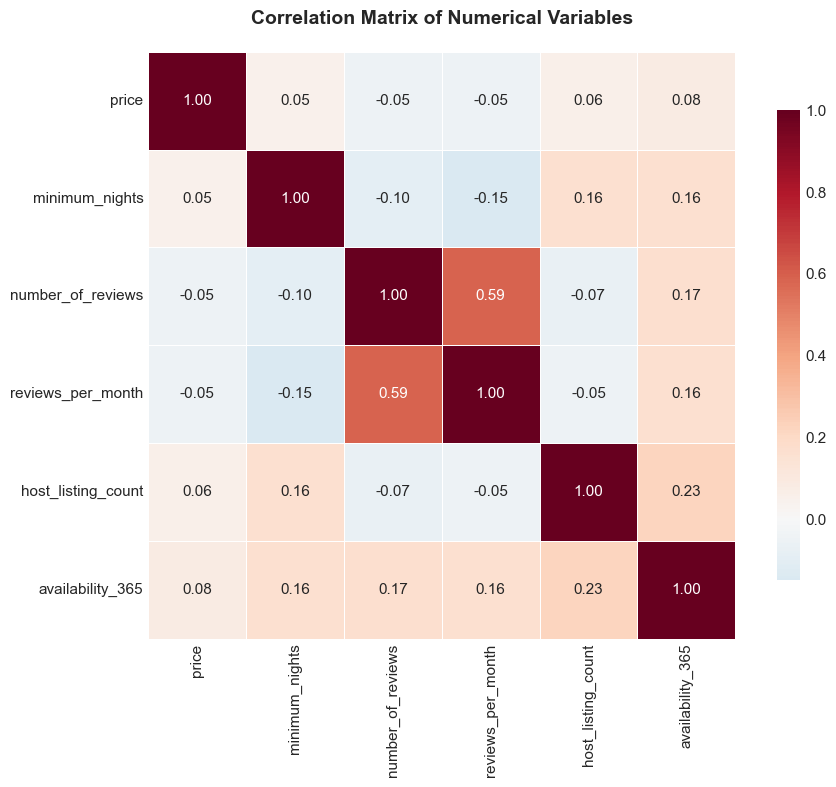

In [17]:

# Compute correlation matrix for numerical columns
corr_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
             'host_listing_count', 'availability_365']
corr_matrix = df[corr_cols].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numerical Variables', pad=20)
plt.tight_layout()
plt.show()

## 4.1 Price Distribution

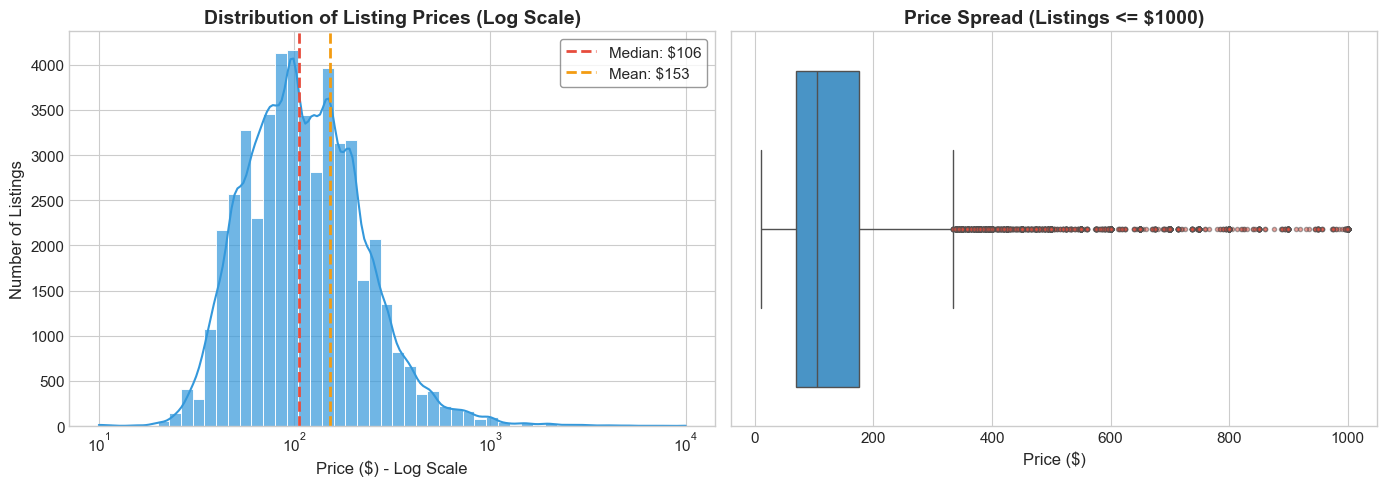

In [18]:
# Price distribution with Log Scale
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Log-scale Histogram (All Prices)
sns.histplot(df['price'], bins=50, log_scale=True, kde=True, color='#3498DB',
             edgecolor='white', alpha=0.7, ax=axes[0])
axes[0].axvline(df['price'].median(), color='#E74C3C', linestyle='--', linewidth=2,
                label=f'Median: ${df["price"].median():.0f}')
axes[0].axvline(df['price'].mean(), color='#F39C12', linestyle='--', linewidth=2,
                label=f'Mean: ${df["price"].mean():.0f}')
axes[0].set_xlabel('Price ($) - Log Scale')
axes[0].set_ylabel('Number of Listings')
axes[0].set_title('Distribution of Listing Prices (Log Scale)')
axes[0].legend(frameon=True, facecolor='white', edgecolor='gray')

# Right: Box plot showing price spread (Up to $1000 for visibility)
# We keep a linear scale here for typical price range clarity, but filter outliers for readability
sns.boxplot(x=df[df['price'] <= 1000]['price'], color='#3498DB', ax=axes[1],
            flierprops={'marker': 'o', 'markerfacecolor': '#E74C3C', 'markersize': 3, 'alpha': 0.5})
axes[1].set_xlabel('Price ($)')
axes[1].set_title('Price Spread (Listings <= $1000)')

plt.tight_layout()
plt.show()

## 4.2 Listings by Borough and Room Type

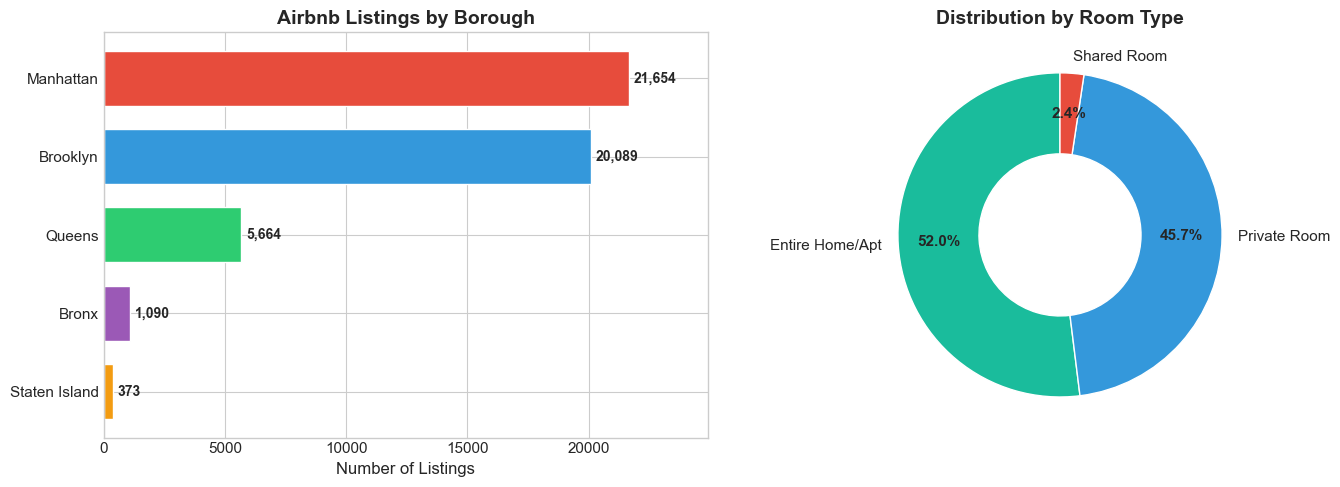

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Horizontal bar chart for boroughs (easier to read)
borough_counts = df['borough'].value_counts()
borough_colors_list = [borough_palette.get(b, '#888888') for b in borough_counts.index]
bars = axes[0].barh(borough_counts.index, borough_counts.values, color=borough_colors_list,
                    edgecolor='white', height=0.7)
axes[0].set_xlabel('Number of Listings')
axes[0].set_ylabel('')
axes[0].set_title('Airbnb Listings by Borough')
axes[0].invert_yaxis()  # Largest at top
# Add value labels
for bar, val in zip(bars, borough_counts.values):
    axes[0].text(val + 200, bar.get_y() + bar.get_height()/2, f'{val:,}',
                 va='center', fontsize=10, fontweight='bold')
axes[0].set_xlim(0, borough_counts.max() * 1.15)

# Right: Donut chart for room types (more modern than pie)
room_counts = df['room_type'].value_counts()
room_colors_list = [room_palette.get(r, '#888888') for r in room_counts.index]
wedges, texts, autotexts = axes[1].pie(room_counts.values, labels=room_counts.index,
                                        autopct='%1.1f%%', colors=room_colors_list,
                                        startangle=90, pctdistance=0.75,
                                        wedgeprops=dict(width=0.5, edgecolor='white'))
axes[1].set_title('Distribution by Room Type')
# Style the percentage text
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

plt.tight_layout()
plt.show()

## 4.3 Price Comparison by Borough and Room Type

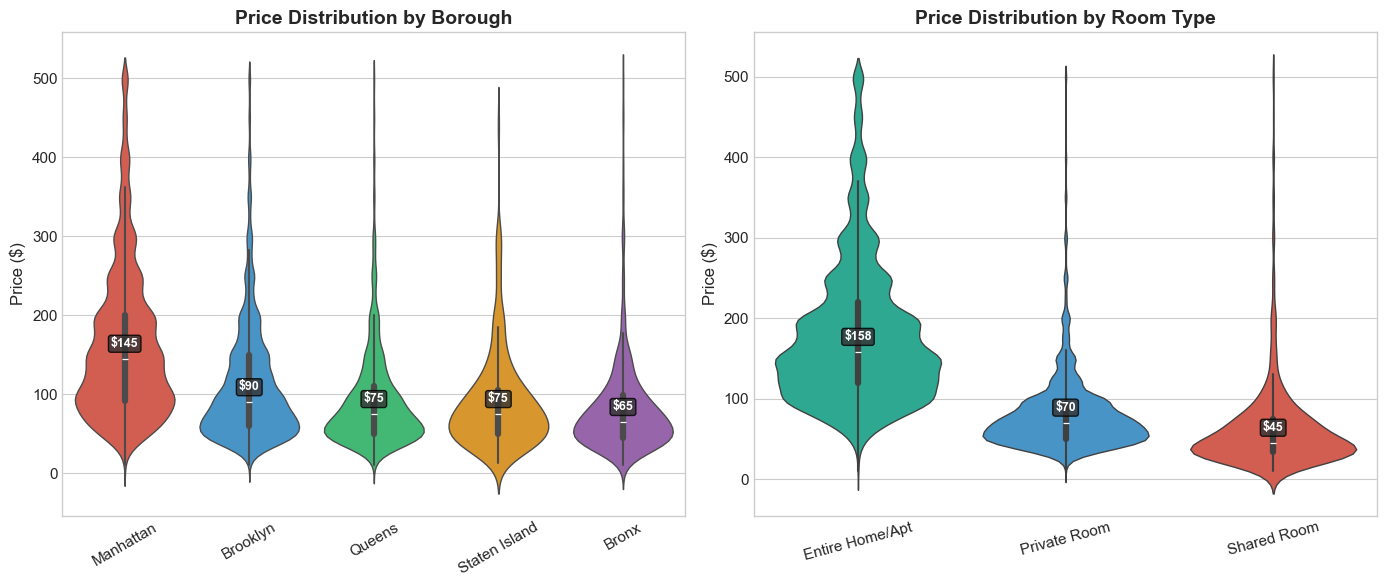

In [20]:
# Violin plots with embedded box plots (more informative than box plots alone)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_filtered = df[df['price'] <= 500]

# Left: Price by Borough - violin plot
borough_order = df_filtered.groupby('borough')['price'].median().sort_values(ascending=False).index
sns.violinplot(data=df_filtered, x='borough', y='price', hue='borough', order=borough_order,
               palette=borough_palette, legend=False, ax=axes[0], inner='box', linewidth=1)
axes[0].set_xlabel('')
axes[0].set_ylabel('Price ($)')
axes[0].set_title('Price Distribution by Borough')
axes[0].tick_params(axis='x', rotation=30)
# Add median labels
medians = df_filtered.groupby('borough')['price'].median()
for i, borough in enumerate(borough_order):
    axes[0].text(i, medians[borough] + 15, f'${medians[borough]:.0f}',
                 ha='center', fontsize=9, fontweight='bold', color='white',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='#333333', alpha=0.8))

# Right: Price by Room Type - violin plot
room_order = df_filtered.groupby('room_type')['price'].median().sort_values(ascending=False).index
sns.violinplot(data=df_filtered, x='room_type', y='price', hue='room_type', order=room_order,
               palette=room_palette, legend=False, ax=axes[1], inner='box', linewidth=1)
axes[1].set_xlabel('')
axes[1].set_ylabel('Price ($)')
axes[1].set_title('Price Distribution by Room Type')
axes[1].tick_params(axis='x', rotation=15)
# Add median labels
medians = df_filtered.groupby('room_type')['price'].median()
for i, room in enumerate(room_order):
    axes[1].text(i, medians[room] + 15, f'${medians[room]:.0f}',
                 ha='center', fontsize=9, fontweight='bold', color='white',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='#333333', alpha=0.8))

plt.tight_layout()
plt.show()

## 4.4 Geographic Distribution of Listings

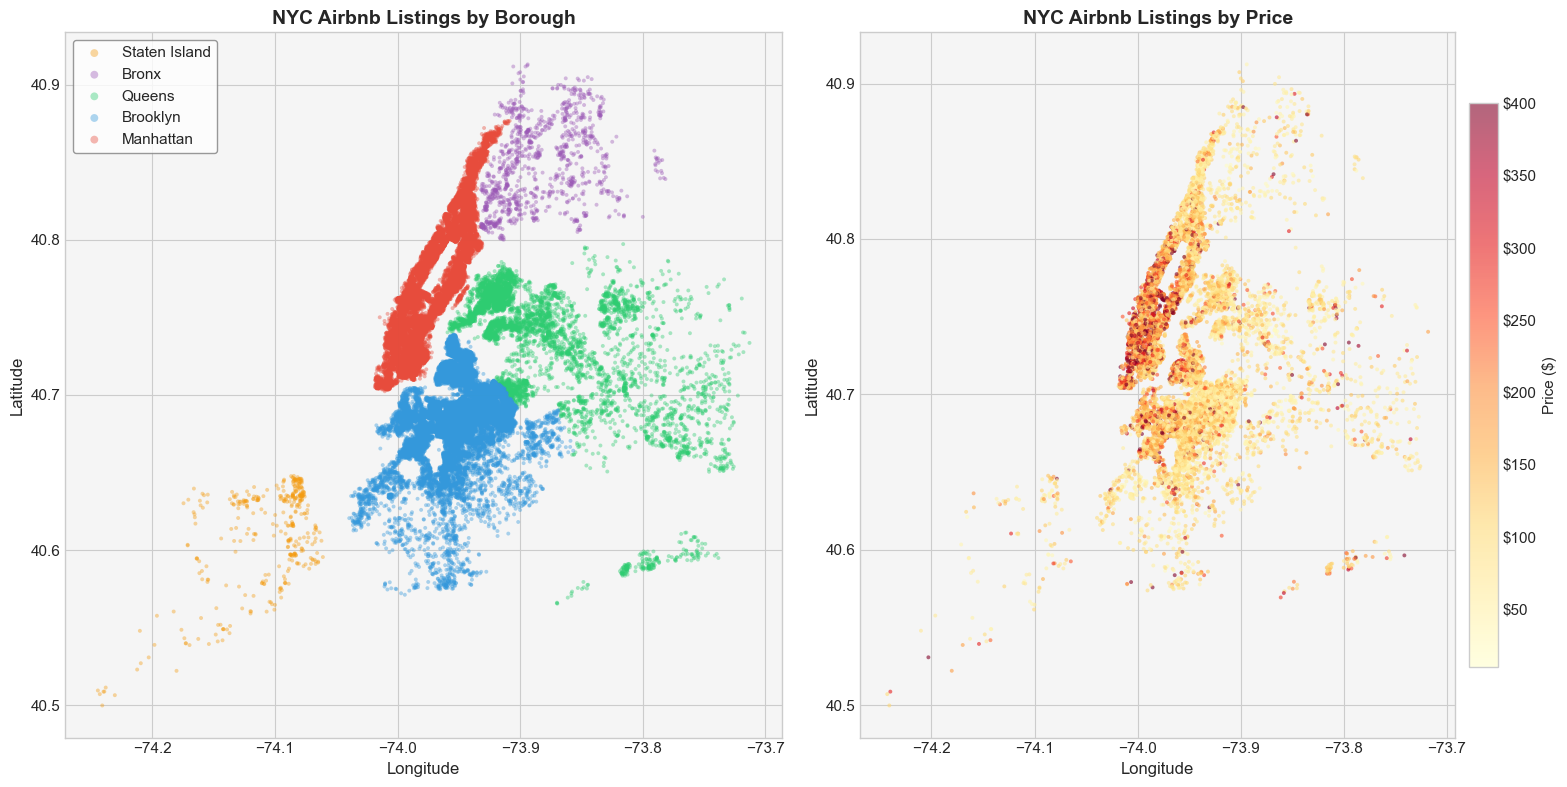

In [21]:
# Geographic visualization with improved styling
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: Listings colored by Borough with better visibility
for borough in ['Staten Island', 'Bronx', 'Queens', 'Brooklyn', 'Manhattan']:  # Order for layering
    subset = df[df['borough'] == borough]
    axes[0].scatter(subset['longitude'], subset['latitude'],
                    c=borough_palette.get(borough), label=borough,
                    alpha=0.4, s=8, edgecolors='none')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('NYC Airbnb Listings by Borough')
axes[0].legend(loc='upper left', frameon=True, facecolor='white',
               edgecolor='gray', markerscale=2)
axes[0].set_facecolor('#f5f5f5')

# Right: Price heatmap style visualization
sample = df.sample(min(15000, len(df)), random_state=42)
scatter = axes[1].scatter(sample['longitude'], sample['latitude'],
                          c=sample['price'].clip(upper=400),
                          cmap='YlOrRd', alpha=0.6, s=8, edgecolors='none')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('NYC Airbnb Listings by Price')
axes[1].set_facecolor('#f5f5f5')

import matplotlib.ticker as ticker

# Add colorbar with better formatting
cbar = plt.colorbar(scatter, ax=axes[1], shrink=0.8, pad=0.02)
cbar.set_label('Price ($)', fontsize=11)
ticks = cbar.get_ticks()
cbar.ax.yaxis.set_major_locator(ticker.FixedLocator(ticks))
cbar.ax.set_yticklabels([f'${int(t)}' for t in ticks])

plt.tight_layout()
plt.show()

## 4.5 Top Neighborhoods and Review Trends

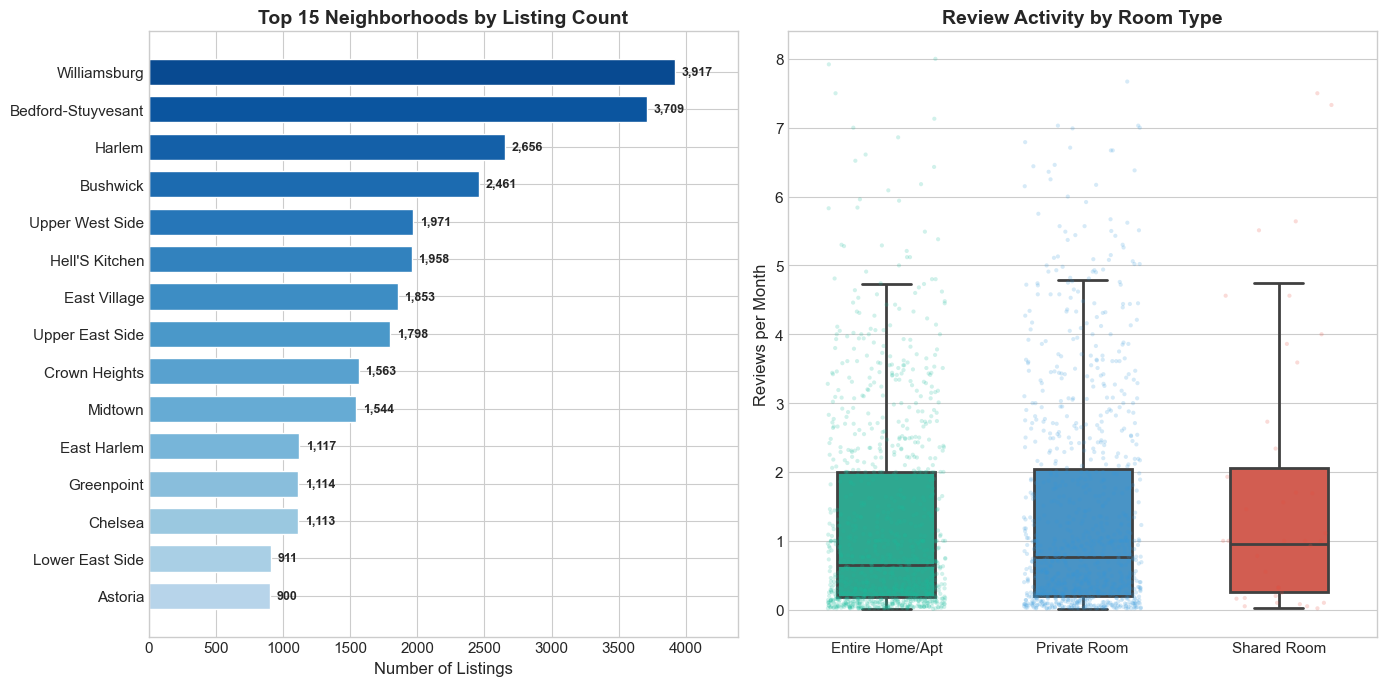

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: Top 15 neighborhoods with gradient coloring
top_neighborhoods = df['neighborhood'].value_counts().head(15)
# Create gradient colors based on rank
gradient_colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(top_neighborhoods)))[::-1]
bars = axes[0].barh(top_neighborhoods.index[::-1], top_neighborhoods.values[::-1],
                    color=gradient_colors[::-1], edgecolor='white', height=0.7)
axes[0].set_xlabel('Number of Listings')
axes[0].set_ylabel('')
axes[0].set_title('Top 15 Neighborhoods by Listing Count')
# Add value labels
for bar, val in zip(bars, top_neighborhoods.values[::-1]):
    axes[0].text(val + 50, bar.get_y() + bar.get_height()/2, f'{val:,}',
                 va='center', fontsize=9, fontweight='bold')
axes[0].set_xlim(0, top_neighborhoods.max() * 1.12)

# Right: Strip plot with box overlay for reviews by room type
df_with_reviews = df[(df['reviews_per_month'] > 0) & (df['reviews_per_month'] <= 8)]
room_order = ['Entire Home/Apt', 'Private Room', 'Shared Room']
sns.boxplot(data=df_with_reviews, x='room_type', y='reviews_per_month', hue='room_type',
            order=room_order, palette=room_palette, legend=False, ax=axes[1],
            width=0.5, linewidth=2, fliersize=0)
sns.stripplot(data=df_with_reviews.sample(min(2000, len(df_with_reviews)), random_state=42),
              x='room_type', y='reviews_per_month', hue='room_type', order=room_order,
              palette=room_palette, legend=False, ax=axes[1], alpha=0.2, size=3, jitter=0.3)
axes[1].set_xlabel('')
axes[1].set_ylabel('Reviews per Month')
axes[1].set_title('Review Activity by Room Type')

plt.tight_layout()
plt.show()

# =============================================================================
# STEP 4B: INTERACTIVE VISUALIZATIONS (PLOTLY)
# =============================================================================

In [23]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Color schemes for Plotly
borough_colors = {
    'Manhattan': '#E74C3C',
    'Brooklyn': '#3498DB',
    'Queens': '#2ECC71',
    'Bronx': '#9B59B6',
    'Staten Island': '#F39C12'
}

room_colors = {
    'Entire Home/Apt': '#1ABC9C',
    'Private Room': '#3498DB',
    'Shared Room': '#E74C3C'
}

## 4B.1 Interactive Price Distribution by Borough

In [24]:
# Interactive histogram with price distribution by borough
df_filtered = df[df['price'] <= 500]

fig = px.histogram(df_filtered, x='price', color='borough',
                   color_discrete_map=borough_colors,
                   nbins=50, barmode='overlay',
                   opacity=0.7,
                   title='Price Distribution by Borough (Interactive)',
                   labels={'price': 'Price ($)', 'borough': 'Borough', 'count': 'Number of Listings'})

fig.update_layout(
    xaxis_title='Price ($)',
    yaxis_title='Number of Listings',
    legend_title='Borough',
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

## 4B.2 Interactive Map of NYC Listings

In [25]:

# Interactive scatter mapbox - sample for performance
sample_map = df.sample(min(5000, len(df)), random_state=42)

fig = px.scatter_mapbox(sample_map,
                        lat='latitude',
                        lon='longitude',
                        color='borough',
                        color_discrete_map=borough_colors,
                        size='price',
                        size_max=15,
                        hover_name='name',
                        hover_data={
                            'price': ':$,.0f',
                            'room_type': True,
                            'neighborhood': True,
                            'latitude': False,
                            'longitude': False
                        },
                        title='NYC Airbnb Listings Map (Interactive)',
                        zoom=10,
                        opacity=0.6)

fig.update_layout(
    mapbox_style='carto-positron',
    mapbox_center={'lat': 40.7128, 'lon': -73.95},
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0},
    legend_title='Borough'
)

fig.show()

/var/folders/fv/_5yfwlg57g38pv619nwc5c_w0000gn/T/ipykernel_6956/1632391620.py:4: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



## 4B.3 Interactive Price Comparison (Box Plots)

In [26]:

# Interactive box plots comparing price by borough and room type
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Price by Borough', 'Price by Room Type'))

df_filtered = df[df['price'] <= 500]

# Box plot by borough
for borough in df_filtered['borough'].unique():
    subset = df_filtered[df_filtered['borough'] == borough]
    fig.add_trace(
        go.Box(y=subset['price'], name=borough,
               marker_color=borough_colors.get(borough),
               boxmean=True),
        row=1, col=1
    )

# Box plot by room type
for room in df_filtered['room_type'].unique():
    subset = df_filtered[df_filtered['room_type'] == room]
    fig.add_trace(
        go.Box(y=subset['price'], name=room,
               marker_color=room_colors.get(room),
               boxmean=True),
        row=1, col=2
    )

fig.update_layout(
    title='Price Distribution Comparison (Interactive)',
    template='plotly_white',
    showlegend=False,
    height=500
)

fig.update_yaxes(title_text='Price ($)', row=1, col=1)
fig.update_yaxes(title_text='Price ($)', row=1, col=2)

fig.show()

## 4B.4 Interactive Sunburst Chart (Borough → Neighborhood → Room Type)

In [27]:

# Sunburst chart showing hierarchy: Borough -> Top Neighborhoods -> Room Type
# Get top 5 neighborhoods per borough for cleaner visualization
top_neighborhoods_per_borough = (df.groupby(['borough', 'neighborhood'])
                                  .size()
                                  .reset_index(name='count')
                                  .sort_values(['borough', 'count'], ascending=[True, False])
                                  .groupby('borough')
                                  .head(5))

df_sunburst = df[df['neighborhood'].isin(top_neighborhoods_per_borough['neighborhood'])]

fig = px.sunburst(df_sunburst,
                  path=['borough', 'neighborhood', 'room_type'],
                  color='borough',
                  color_discrete_map=borough_colors,
                  title='Listing Hierarchy: Borough → Neighborhood → Room Type')

fig.update_layout(
    margin={'t': 50, 'l': 0, 'r': 0, 'b': 0}
)

fig.show()

## 4B.5 Interactive Scatter: Price vs Reviews

In [28]:

# Interactive scatter plot: Price vs Number of Reviews
sample_scatter = df[(df['price'] <= 500) & (df['number_of_reviews'] > 0)].sample(min(3000, len(df)), random_state=42)

fig = px.scatter(sample_scatter,
                 x='number_of_reviews',
                 y='price',
                 color='room_type',
                 color_discrete_map=room_colors,
                 size='availability_365',
                 size_max=20,
                 hover_name='name',
                 hover_data={
                     'borough': True,
                     'neighborhood': True,
                     'price': ':$,.0f',
                     'number_of_reviews': True,
                     'availability_365': True
                 },
                 opacity=0.6,
                 title='Price vs Number of Reviews (size = availability)')

fig.update_layout(
    xaxis_title='Number of Reviews',
    yaxis_title='Price ($)',
    template='plotly_white',
    legend_title='Room Type'
)

fig.show()

# =============================================================================
# STEP 5: EXPORT TO SQLITE DATABASE
# =============================================================================

In [29]:

import sqlite3

# Create SQLite database
db_path = 'nyc_airbnb.db'
conn = sqlite3.connect(db_path)

# Export cleaned DataFrame to SQLite table
# Convert datetime to string for SQLite compatibility
df_export = df.copy()
df_export['last_review'] = df_export['last_review'].astype(str).replace('NaT', None)

# Export to database
df_export.to_sql('listings', conn, if_exists='replace', index=False)

print(f"Database created: {db_path}")
print(f"Table 'listings' created with {len(df_export):,} records")

Database created: nyc_airbnb.db
Table 'listings' created with 48,870 records


## 5.1 Verify Database Export

In [30]:

# Verify the data was exported correctly
cursor = conn.cursor()

# Check table exists and get schema
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print("Tables in database:", cursor.fetchall())

# Get column info
cursor.execute("PRAGMA table_info(listings);")
print("\n--- Table Schema ---")
for col in cursor.fetchall():
    print(f"  {col[1]}: {col[2]}")

# Count records
cursor.execute("SELECT COUNT(*) FROM listings;")
print(f"\nTotal records in database: {cursor.fetchone()[0]:,}")

# Sample query
print("\n--- Sample Query: Top 5 listings by price ---")
query = "SELECT name, borough, neighborhood, room_type, price FROM listings ORDER BY price DESC LIMIT 5"
sample_df = pd.read_sql_query(query, conn)
print(sample_df.to_string(index=False))

# Close connection
conn.close()
print(f"\nDatabase connection closed. File saved as: {db_path}")

Tables in database: [('listings',)]

--- Table Schema ---
  id: INTEGER
  name: TEXT
  host_id: INTEGER
  host_name: TEXT
  borough: TEXT
  neighborhood: TEXT
  latitude: REAL
  longitude: REAL
  room_type: TEXT
  price: INTEGER
  minimum_nights: INTEGER
  number_of_reviews: INTEGER
  last_review: TEXT
  reviews_per_month: REAL
  host_listing_count: INTEGER
  availability_365: INTEGER

Total records in database: 48,870

--- Sample Query: Top 5 listings by price ---
                                           name   borough    neighborhood       room_type  price
            Furnished room in Astoria apartment    Queens         Astoria    Private Room  10000
Luxury 1 bedroom apt. -stunning Manhattan views  Brooklyn      Greenpoint Entire Home/Apt  10000
                            1-BR Lincoln Center Manhattan Upper West Side Entire Home/Apt  10000
                             Spanish Harlem Apt Manhattan     East Harlem Entire Home/Apt   9999
            Quiet, Clean, Lit @ LES & Chinato